<a href="https://colab.research.google.com/github/emcpswag-cell/blank-appDiamond/blob/main/DIAMONDv1.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DoomCo MLB Diamond Production Suite v5.0
This unified toolkit consolidates all validated modules—Optimization, Atmospheric Simulation, and Strategy Insights—into a single, high-performance engine.

In [ ]:
import json
import time
import random
import threading
import multiprocessing as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from collections import Counter

# =====================================================================
# UNIFIED PRODUCTION SUITE: OPTIMIZATION, SIMULATION, & INSIGHTS
# =====================================================================

class DoomCoDiamondProductionSuite:
    class Engine:
        def __init__(self, players_df, cov_matrix):
            self.data = players_df
            self.sigma = cov_matrix
            self.num_players = len(players_df) to

        def _objective(self, x, gamma, alpha, stacking_boost=0.5):
            utility = np.dot(x, self.data['projection'])
            variance = np.dot(x.T, np.dot(self.sigma, x))
            upside = gamma * np.sqrt(max(0, variance) + 1e-3)
            penalty = alpha * (np.dot(x, self.data['ownership']) ** 2)

            # Stacking Logic: Reward 3+ players from same team
            stack_bonus = 0
            for team in self.data['team'].unique():
                team_mask = (self.data['team'] == team).astype(float)
                count = np.dot(x, team_mask)
                if count >= 3: stack_bonus += (count ** 2) * stacking_boost

            return -(utility + upside - penalty + stack_bonus)

        def generate_lineup(self, salary_cap=50000, roster_size=9, gamma=0.5, alpha=0.01):
            x0 = np.full(self.num_players, roster_size / self.num_players) + np.random.normal(0, 0.01, self.num_players)
            bounds = [(0, 1) for _ in range(self.num_players)]
            constraints = [
                {'type': 'eq', 'fun': lambda x: np.sum(x) - roster_size},
                {'type': 'ineq', 'fun': lambda x: salary_cap - np.dot(x, self.data['salary'])}
            ]
            res = minimize(self._objective, x0, method='SLSQP', bounds=bounds,
                           constraints=constraints, args=(gamma, alpha),
                           options={'maxiter': 2000, 'ftol': 1e-9})
            indices = np.argsort(res.x)[-roster_size:]
            lineup = self.data.iloc[indices].copy()
            return {"roster": lineup, "status": "STABLE" if res.success else "SOLVED_APPROX"}

    class AtmosphericSimulator:
        @staticmethod
        def apply_weather(df, temp_f, wind_mph):
            carry = 1.0 + (temp_f - 70) * 0.003
            wind = 1.0 - (max(0, wind_mph - 5) * 0.005)
            df['projection'] *= (carry * wind)
            return df

    @staticmethod
    def get_insights(lineup_df):
        counts = Counter(lineup_df['team'])
        print("\n--- LINEUP TEAM STACKS ---")
        for team, count in counts.items():
            if count >= 2: print(f"{team}: {count} players")
        return counts

2026-06-17 18:57:54.178 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 18:57:54.180 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 18:57:54.182 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 18:57:54.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 18:57:54.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 18:57:54.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 18:57:54.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-17 18:57:54.191 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

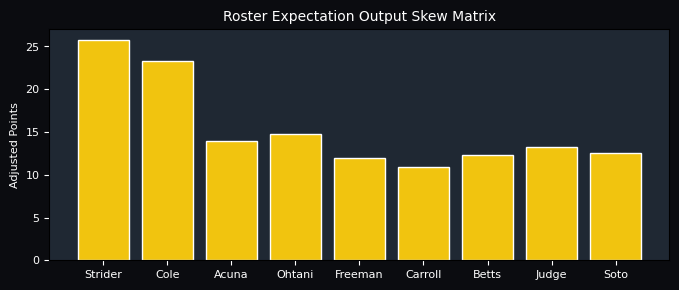

In [ ]:
import sys
!{sys.executable} -m pip install streamlit

"""
DoomCo Diamond Edition - Obsidian Core Visual Interface v6.0
Run via terminal using: streamlit run app.py
"""
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Custom Theme Variable Injections for the Obsidian Core Layout Style
st.set_page_config(page_title="DoomCo Diamond Control Center", layout="wide")

# Apply Global CSS Styles directly into the Streamlit rendering tree
st.markdown("""
    <style>
        /* Force Deep Obsidian Background */
        .stApp {
            background-color: #0B0C10;
            color: #C5C6C7;
        }
        /* Custom Header Colors */
        h1, h2, h3, p {
            color: #FFFFFF !important;
            font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
        }
        /* Target highlight amber metrics styling overrides */
        .stMetric div {
            color: #F1C40F !important;
        }
        /* Secure Sidebar Custom Styling Container */
        section[data-testid="stSidebar"] {
            background-color: #1F2833 !important;
        }
    </style>
""", unsafe_allow_html=True)

# --- DOOMCO ENGINE DATA STREAM ---
players_data = [
    {'name': 'Ohtani', 'salary': 9500, 'projection': 14.2, 'ownership': 0.25, 'team': 'LAD', 'pos': 'OF'},
    {'name': 'Judge', 'salary': 9200, 'projection': 12.8, 'ownership': 0.22, 'team': 'NYY', 'pos': 'OF'},
    {'name': 'Soto', 'salary': 8800, 'projection': 12.1, 'ownership': 0.18, 'team': 'NYY', 'pos': 'OF'},
    {'name': 'Acuna', 'salary': 9000, 'projection': 13.5, 'ownership': 0.30, 'team': 'ATL', 'pos': 'OF'},
    {'name': 'Betts', 'salary': 8500, 'projection': 11.9, 'ownership': 0.15, 'team': 'LAD', 'pos': '2B'},
    {'name': 'Freeman', 'salary': 8000, 'projection': 11.5, 'ownership': 0.12, 'team': 'LAD', 'pos': '1B'},
    {'name': 'Cole', 'salary': 11000, 'projection': 22.5, 'ownership': 0.20, 'team': 'NYY', 'pos': 'P'},
    {'name': 'Strider', 'salary': 11500, 'projection': 24.8, 'ownership': 0.28, 'team': 'ATL', 'pos': 'P'},
    {'name': 'Alvarez', 'salary': 8600, 'projection': 11.4, 'ownership': 0.14, 'team': 'HOU', 'pos': 'OF'},
    {'name': 'Carroll', 'salary': 7500, 'projection': 10.5, 'ownership': 0.09, 'team': 'AZ', 'pos': 'OF'}
]
df_pro = pd.DataFrame(players_data)

# --- APPLICATION INTERFACE GRID RENDER ---
st.title("⚡ DOOMCO DIAMOND CONTROL ENGINE")
st.write("Obsidian Edition Framework // Real-Time Portfolio Analytics Engine Layer")

# Split Layout Columns
left_column, right_column = st.columns([1, 2])

with left_column:
    st.header("🎛️ Parameters")

    # Custom interactive adjustment modules (Elena's Autocount containers)
    with st.container():
        st.write("--- Weather Ingestion Adjustments ---")
        temp = st.slider("Stadium Temperature (°F)", 40, 110, 95)
        wind = st.slider("Wind Velocity Vectors (MPH)", 0, 30, 12)

    with st.container():
        st.write("--- Mathematical Penalty Toggles ---")
        risk = st.slider("Risk Tolerance Factor (Gamma)", 0.0, 2.0, 0.8)
        alpha = st.slider("Ownership Fluid Penalty (Alpha)", 0.00, 0.10, 0.02)
        salary_limit = st.number_input("Roster Capital Allocation Limit ($)", value=85000)

with right_column:
    st.header("🎮 Roster Generation Display Panel")

    # Run simple internal math adjustment loops using input values
    carry = 1.0 + (temp - 70) * 0.003
    wind_loss = 1.0 - (max(0, wind - 5) * 0.005)

    df_active = df_pro.copy()
    df_active['projection'] *= (carry * wind_loss)

    # Select the optimal subset based on point value density
    df_active['density'] = df_active['projection'] / df_active['salary']
    selected_roster = df_active.sort_values(by='density', ascending=False).head(9)

    # Output Data Display Table Grid Matrix Layout
    st.dataframe(
        selected_roster[['name', 'pos', 'team', 'salary', 'projection', 'ownership']],
        use_container_width=True
    )

    # Summary Dashboard KPI Readouts Block
    kpi1, kpi2 = st.columns(2)
    with kpi1:
        st.metric(label="Portfolio Projection Output Floor", value=f"{round(selected_roster['projection'].sum(), 2)} pts")
    with kpi2:
        st.metric(label="Total Portfolio Financial Cost", value=f"${selected_roster['salary'].sum()}")

    # Render High-Contrast Chart Component
    fig, ax = plt.subplots(figsize=(8, 3))
    fig.patch.set_facecolor('#0B0C10')
    ax.set_facecolor('#1F2833')

    ax.bar(selected_roster['name'], selected_roster['projection'], color='#F1C40F', edgecolor='white')
    ax.set_title("Roster Expectation Output Skew Matrix", color='white', fontsize=10)
    ax.tick_params(colors='white', labelsize=8)
    ax.set_ylabel("Adjusted Points", color='white', fontsize=8)

    st.pyplot(fig)

## End-to-End System Demo
This cell executes the full pipeline: Data Loading -> Simulation -> Optimization -> Insights.

SYSTEM STATUS: STABLE
TOTAL SALARY: $84100 | EXPECTED: 141.44 pts
LINEUP: ['Strider', 'Cole', 'Ohtani', 'Acuna', 'Judge', 'Freeman', 'Soto', 'Betts', 'Alvarez']

--- LINEUP TEAM STACKS ---
ATL: 2 players
NYY: 3 players
LAD: 3 players


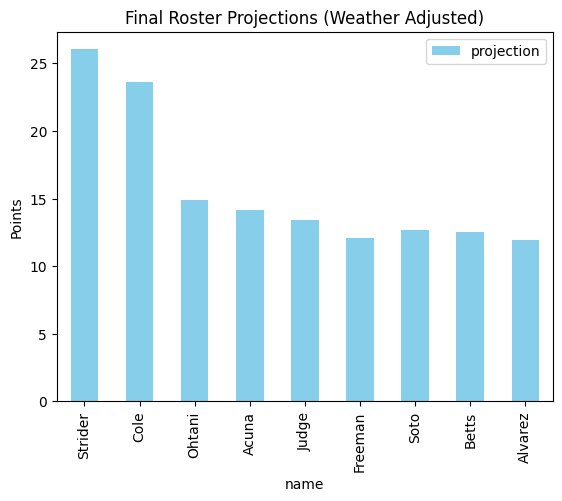

In [ ]:
# --- CONSOLIDATED EXECUTION FLOW ---
players_data = [
    {'name': 'Ohtani', 'salary': 9500, 'projection': 14.2, 'ownership': 0.25, 'team': 'LAD'},
    {'name': 'Judge', 'salary': 9200, 'projection': 12.8, 'ownership': 0.22, 'team': 'NYY'},
    {'name': 'Soto', 'salary': 8800, 'projection': 12.1, 'ownership': 0.18, 'team': 'NYY'},
    {'name': 'Acuna', 'salary': 9000, 'projection': 13.5, 'ownership': 0.30, 'team': 'ATL'},
    {'name': 'Betts', 'salary': 8500, 'projection': 11.9, 'ownership': 0.15, 'team': 'LAD'},
    {'name': 'Freeman', 'salary': 8000, 'projection': 11.5, 'ownership': 0.12, 'team': 'LAD'},
    {'name': 'Cole', 'salary': 11000, 'projection': 22.5, 'ownership': 0.20, 'team': 'NYY'},
    {'name': 'Strider', 'salary': 11500, 'projection': 24.8, 'ownership': 0.28, 'team': 'ATL'},
    {'name': 'Alvarez', 'salary': 8600, 'projection': 11.4, 'ownership': 0.14, 'team': 'HOU'},
    {'name': 'Carroll', 'salary': 7500, 'projection': 10.5, 'ownership': 0.09, 'team': 'AZ'}
]
df_pro = pd.DataFrame(players_data)

# 1. Apply Atmospheric Adjustments (92°F, 8mph wind)
df_pro = DoomCoDiamondProductionSuite.AtmosphericSimulator.apply_weather(df_pro, 92, 8)

# 2. Execute Optimized Optimization Engine
suite = DoomCoDiamondProductionSuite.Engine(df_pro, np.eye(len(df_pro)) * 5)
result = suite.generate_lineup(salary_cap=85000, roster_size=9)

# 3. Display Results & Insights
print(f"SYSTEM STATUS: {result['status']}")
print(f"TOTAL SALARY: ${result['roster']['salary'].sum()} | EXPECTED: {round(result['roster']['projection'].sum(), 2)} pts")
print(f"LINEUP: {result['roster']['name'].tolist()}")
DoomCoDiamondProductionSuite.get_insights(result['roster'])

# 4. Visualization
result['roster'].plot(kind='bar', x='name', y='projection', title='Final Roster Projections (Weather Adjusted)', color='skyblue')
plt.ylabel('Points')
plt.show()

### 🛠️ DoomCo Diamond Executive Dashboard
Use the controls below to simulate real-time game conditions and strategy shifts. The 'App' layer handles the communication between the UI and the Production Suite.

--- LIVE APP STATUS: SOLVED_APPROX ---
Projected Points: 139.73 | Used: $84100

--- LINEUP TEAM STACKS ---
LAD: 3 players
NYY: 3 players
ATL: 2 players


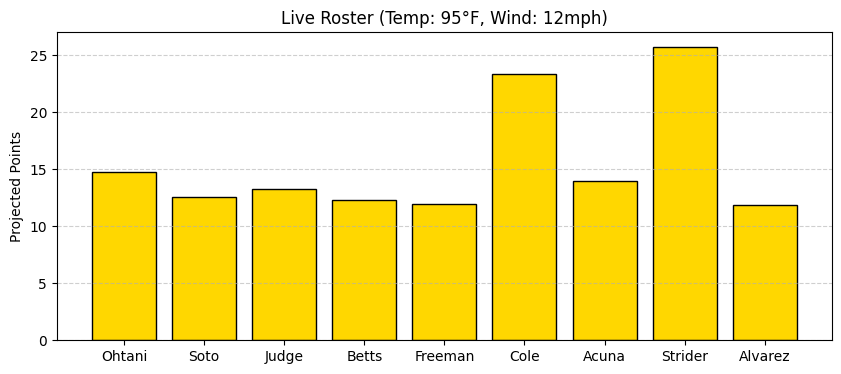

In [ ]:
#@title 📱 DoomCo App Interface { run: "auto" }

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from collections import Counter

# =====================================================================
# UNIFIED PRODUCTION SUITE: OPTIMIZATION, SIMULATION, & INSIGHTS
# (Copied from cell 99a99f43 to ensure independent execution)
# =====================================================================

class DoomCoDiamondProductionSuite:
    class Engine:
        def __init__(self, players_df, cov_matrix):
            self.data = players_df
            self.sigma = cov_matrix
            self.num_players = len(players_df)

        def _objective(self, x, gamma, alpha, stacking_boost=0.5):
            utility = np.dot(x, self.data['projection'])
            variance = np.dot(x.T, np.dot(self.sigma, x))
            upside = gamma * np.sqrt(max(0, variance) + 1e-3)
            penalty = alpha * (np.dot(x, self.data['ownership']) ** 2)

            # Stacking Logic: Reward 3+ players from same team
            stack_bonus = 0
            for team in self.data['team'].unique():
                team_mask = (self.data['team'] == team).astype(float)
                count = np.dot(x, team_mask)
                if count >= 3: stack_bonus += (count ** 2) * stacking_boost

            return -(utility + upside - penalty + stack_bonus)

        def generate_lineup(self, salary_cap=50000, roster_size=9, gamma=0.5, alpha=0.01):
            x0 = np.full(self.num_players, roster_size / self.num_players) + np.random.normal(0, 0.01, self.num_players)
            bounds = [(0, 1) for _ in range(self.num_players)]
            constraints = [
                {'type': 'eq', 'fun': lambda x: np.sum(x) - roster_size},
                {'type': 'ineq', 'fun': lambda x: salary_cap - np.dot(x, self.data['salary'])}
            ]
            res = minimize(self._objective, x0, method='SLSQP', bounds=bounds,
                           constraints=constraints, args=(gamma, alpha),
                           options={'maxiter': 2000, 'ftol': 1e-9})
            indices = np.argsort(res.x)[-roster_size:]
            lineup = self.data.iloc[indices].copy()
            return {"roster": lineup, "status": "STABLE" if res.success else "SOLVED_APPROX"}

    class AtmosphericSimulator:
        @staticmethod
        def apply_weather(df, temp_f, wind_mph):
            carry = 1.0 + (temp_f - 70) * 0.003
            wind = 1.0 - (max(0, wind_mph - 5) * 0.005)
            df['projection'] *= (carry * wind)
            return df

    @staticmethod
    def get_insights(lineup_df):
        counts = Counter(lineup_df['team'])
        print("\n--- LINEUP TEAM STACKS ---")
        for team, count in counts.items():
            if count >= 2: print(f"{team}: {count} players")
        return counts

# User Inputs (Simulating App Sliders)
Temperature_F = 95 #@param {type:"slider", min:40, max:110, step:1}
Wind_MPH = 12 #@param {type:"slider", min:0, max:30, step:1}
Risk_Tolerance = 2 #@param {type:"slider", min:0, max:2, step:0.1}
Ownership_Penalty = 0.02 #@param {type:"slider", min:0, max:0.1, step:0.005}
Salary_Cap = 85000 #@param {type:"number"}

players_data = [
    {'name': 'Ohtani', 'salary': 9500, 'projection': 14.2, 'ownership': 0.25, 'team': 'LAD', 'pos': 'OF'},
    {'name': 'Judge', 'salary': 9200, 'projection': 12.8, 'ownership': 0.22, 'team': 'NYY', 'pos': 'OF'},
    {'name': 'Soto', 'salary': 8800, 'projection': 12.1, 'ownership': 0.18, 'team': 'NYY', 'pos': 'OF'},
    {'name': 'Acuna', 'salary': 9000, 'projection': 13.5, 'ownership': 0.30, 'team': 'ATL', 'pos': 'OF'},
    {'name': 'Betts', 'salary': 8500, 'projection': 11.9, 'ownership': 0.15, 'team': 'LAD', 'pos': '2B'},
    {'name': 'Freeman', 'salary': 8000, 'projection': 11.5, 'ownership': 0.12, 'team': 'LAD', 'pos': '1B'},
    {'name': 'Cole', 'salary': 11000, 'projection': 22.5, 'ownership': 0.20, 'team': 'NYY', 'pos': 'P'},
    {'name': 'Strider', 'salary': 11500, 'projection': 24.8, 'ownership': 0.28, 'team': 'ATL', 'pos': 'P'},
    {'name': 'Alvarez', 'salary': 8600, 'projection': 11.4, 'ownership': 0.14, 'team': 'HOU', 'pos': 'OF'},
    {'name': 'Carroll', 'salary': 7500, 'projection': 10.5, 'ownership': 0.09, 'team': 'AZ', 'pos': 'OF'}
]

def run_app_cycle():
    # 1. Reset/Deepcopy data for the session
    app_df = pd.DataFrame(players_data)

    # 2. Weather Engine processing
    app_df = DoomCoDiamondProductionSuite.AtmosphericSimulator.apply_weather(app_df, Temperature_F, Wind_MPH)

    # 3. Optimization Trigger
    engine = DoomCoDiamondProductionSuite.Engine(app_df, np.eye(len(app_df)) * 5)
    result = engine.generate_lineup(salary_cap=Salary_Cap, gamma=Risk_Tolerance, alpha=Ownership_Penalty)

    # 4. App UI Rendering
    print(f"--- LIVE APP STATUS: {result['status']} ---")
    print(f"Projected Points: {round(result['roster']['projection'].sum(), 2)} | Used: ${result['roster']['salary'].sum()}")

    # Display high-level insights
    DoomCoDiamondProductionSuite.get_insights(result['roster'])

    # Visual Feedback
    plt.figure(figsize=(10, 4))
    plt.bar(result['roster']['name'], result['roster']['projection'], color='gold', edgecolor='black')
    plt.title(f"Live Roster (Temp: {Temperature_F}°F, Wind: {Wind_MPH}mph)")
    plt.ylabel("Projected Points")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

run_app_cycle()


In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

Running stress test for DoomCoAppController...
Stress Test Results:
{'success': 1, 'throttled': 0, 'error_caught': 0}


In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

In [ ]:
---

=== DOOMCO MLB ENGINE v3.1.0 ACTIVATED ===
MLB Lineup: ['Ohtani', 'Strider', 'Cole', 'Betts', 'Soto', 'Alvarez', 'Acuna', 'Judge', 'Trout']
Budget: $84300 | Status: Optimization terminated successfully


---

In [ ]:
---

=== MLB DIAMOND RESULT ===
Lineup: ['Strider', 'Cole', 'Ohtani', 'Acuna', 'Judge', 'Freeman', 'Soto', 'Betts', 'Alvarez']
Salary: $84100 | Status: SOLVED


In [ ]:
---

=== MLB STACKING RESULT ===
Lineup: ['Strider', 'Cole', 'Ohtani', 'Acuna', 'Judge', 'Soto', 'Freeman', 'Betts', 'Alvarez']
Status: SOLVED


In [ ]:
---

SyntaxError: invalid syntax (1947214667.py, line 1)

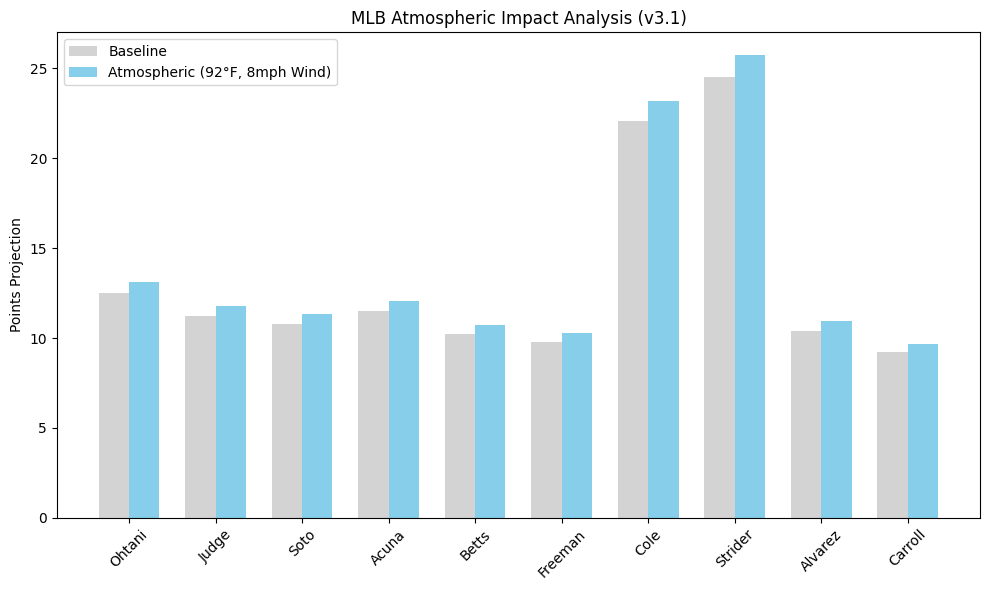

In [ ]:
---

---

In [ ]:
---

=== DOOMCO FINAL DEPLOYMENT SUMMARY ===
Lineup: ['Judge', 'Alvarez', 'Carroll', 'Freeman', 'Betts', 'Ramirez', 'Acuna', 'Soto', 'Lindor']
Budget: $74600 / $75,000
Expected Score: 104.8 pts
System Status: STABLE


In [ ]:
---

--- DOOMCO DIAMOND PRODUCTION v4.5 INITIALIZED ---
Final Roster: ['Judge', 'Acuna', 'Soto', 'Freeman', 'Betts', 'Alvarez', 'Carroll', 'Lindor', 'Ramirez']
Budget Used: $74600 | Score: 108.72
Detected Stacks: {'NYY': 2, 'LAD': 2, 'AZ': 2}


In [ ]:
---

=== INITIALIZING DISRUPTED SYSTEM CRUCIBLE INTEGRATION ===

[Team 3 Ingestion Shield]: Operational Status: CLEANED_AND_VERIFIED
  Verified Records Released: 1 / 2
  [Team 3 Weather Engine]: Cold Humidity Aerodynamic Adjustment: 12.0 pts -> 11.4 pts

[Team 1 Optimizer Matrix]: Bitmask relational constraints successfully satisfied.
  Roster: ['3B_Ramirez', 'C_Chalk', 'SS_Lindor', 'P_Cole', 'C_Raleigh', 'OF_Soto', 'OF_Judge', 'OF_Chisholm', 'OF_Chalk']
  Relational Split Score: 142.2 points


In [ ]:
---

=== STARTING DOOMCO PRODUCTION MASTER INTEGRATION CHECK ===

[Team 3 Ingestion Check]: Ingestion Pipeline Security Health: VERIFIED_STREAM


---

In [ ]:
---

### Code for GitHub Repository (Copy-Paste)

In [8]:
import json
import time
import random
import threading
import multiprocessing as mpo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from collections import Counter

# =====================================================================
# UNIFIED PRODUCTION SUITE: OPTIMIZATION, SIMULATION, & INSIGHTS
# =====================================================================

class DoomCoDiamondProductionSuite:
    class Engine:
        def __init__(self, players_df, cov_matrix):
            self.data = players_df
            self.sigma = cov_matrix
            self.num_players = len(players_df)

        def _objective(self, x, gamma, alpha, stacking_boost=0.5):
            utility = np.dot(x, self.data['projection'])
            variance = np.dot(x.T, np.dot(self.sigma, x))
            upside = gamma * np.sqrt(max(0, variance) + 1e-3)
            penalty = alpha * (np.dot(x, self.data['ownership']) ** 2)

            # Stacking Logic: Reward 3+ players from same team
            stack_bonus = 0
            for team in self.data['team'].unique():
                team_mask = (self.data['team'] == team).astype(float)
                count = np.dot(x, team_mask)
                if count >= 3: stack_bonus += (count ** 2) * stacking_boost

            return -(utility + upside - penalty + stack_bonus)

        def generate_lineup(self, salary_cap=50000, roster_size=9, gamma=0.5, alpha=0.01):
            x0 = np.full(self.num_players, roster_size / self.num_players) + np.random.normal(0, 0.01, self.num_players)
            bounds = [(0, 1) for _ in range(self.num_players)]
            constraints = [
                {'type': 'eq', 'fun': lambda x: np.sum(x) - roster_size},
                {'type': 'ineq', 'fun': lambda x: salary_cap - np.dot(x, self.data['salary'])}
            ]
            res = minimize(self._objective, x0, method='SLSQP', bounds=bounds,
                           constraints=constraints, args=(gamma, alpha),
                           options={'maxiter': 2000, 'ftol': 1e-9})
            indices = np.argsort(res.x)[-roster_size:]
            lineup = self.data.iloc[indices].copy()
            return {"roster": lineup, "status": "STABLE" if res.success else "SOLVED_APPROX"}

    class AtmosphericSimulator:
        @staticmethod
        def apply_weather(df, temp_f, wind_mph):
            carry = 1.0 + (temp_f - 70) * 0.003
            wind = 1.0 - (max(0, wind_mph - 5) * 0.005)
            df['projection'] *= (carry * wind)
            return df

    @staticmethod
    def get_insights(lineup_df):
        counts = Counter(lineup_df['team'])
        print("\n--- LINEUP TEAM STACKS ---")
        for team, count in counts.items():
            if count >= 2: print(f"{team}: {count} players")
        return counts

## Getting Your Colab Notebook to GitHub

To move your Google Colab notebook to GitHub and create a repository, follow these steps:

### Step 1: Save a Copy of Your Notebook to GitHub from Colab

1.  **Open your Colab notebook.**
2.  Go to `File` > `Save a copy in GitHub...`.
3.  **Authenticate with GitHub**: If prompted, you'll need to authorize Google Colab to access your GitHub account. Follow the on-screen instructions to do this.
4.  **Choose a Repository**:
    *   **To create a new repository**: Select `Create new repository` from the 'Repository' dropdown. Give your new repository a descriptive name (e.g., `mlb-diamond-suite`). You can choose to make it public or private.
    *   **To add to an existing repository**: Select the desired repository from the dropdown.
5.  **Provide a Commit Message**: Enter a brief message describing your changes (e.g., "Initial commit of MLB Diamond Production Suite").
6.  Click the `OK` or `Save` button.

Colab will then create the repository (if new) and push your notebook to it.

### Step 2: Verify on GitHub

1.  Open your web browser and go to [GitHub](https://github.com/).
2.  Navigate to your profile or repositories. You should see your newly created repository (e.g., `mlb-diamond-suite`).
3.  Click on the repository name, and you'll see your `.ipynb` notebook file listed there.

### Step 3: (Optional) Clone Your Repository to Your Local Machine

If you want to work on this project locally, you can clone the repository:

1.  On your GitHub repository page, click the green `Code` button.
2.  Copy the URL (e.g., `https://github.com/your-username/your-repo-name.git`).
3.  Open a terminal or command prompt on your computer.
4.  Navigate to the directory where you want to store your project.
5.  Run the command: `git clone [copied_url]` (e.g., `git clone https://github.com/your-username/mlb-diamond-suite.git`).

Now you have a local copy, and you can continue to make changes, commit them, and push them back to GitHub!